In [ ]:
import os
import scanpy as sc
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import numpy as np
import pickle
import re
import anndata as ad
import muon as mu
import seaborn as sns
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import zscore

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Load data and process metadata

In [ ]:
annotation = 'annotation_coarse'

wd = '../data/validations/AT410_E25_E30/'
plot_dir = '../data/validations/plots/'
sc.settings.figdir = plot_dir
sample_list = glob.glob(wd+"/*log1p*h5ad")
sample_list = [i for i in sample_list if '0_25' in i] # remove 0.5

color_palette = {
    "Gliosis-like": "#cd853f",
    "AC-gliosis-like": "#a0522d",
    "Hypoxic": "#bc8f8f",
    "AC-progenitor-like": "#8b4513",
    
    "NPC-neuronal-like": "#c0bdbd",
    
    "OPC-like": "#c0d860",
    "OPC-NPC-like": "#9ec85e",
    "OPC-neuronal-like": "#acd748",
    
    "Proliferative": "#35aee3",
    "NA": "#D3D3D3"
}

malignant_cts = [
 'Hypoxic',
 'Gliosis-like',
 'AC-gliosis-like',
 'AC-progenitor-like',
 'Proliferative',
 'NPC-neuronal-like',
 'OPC-NPC-like',
 'OPC-neuronal-like',
 'OPC-like']

annotation_hierarchy = pd.read_csv('../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', 
                                   sep = '\t')

In [ ]:
sc_dir = '../data/validations/'
adata_full_obs = pd.read_csv(os.path.join(sc_dir, "combined_label_transfer/adata_combined_nohvg_all_obs_prolif.csv"), index_col=0)
adata_full_obs['batch'] = [re.sub('^.*/', '', i) for i in adata_full_obs['batch_category']]

/tmp/ipykernel_1444789/1694799882.py:2: DtypeWarning: Columns (2,14) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_full_obs = pd.read_csv(os.path.join(sc_dir, "combined_label_transfer/adata_combined_nohvg_all_obs_prolif.csv"), index_col=0)


In [ ]:
sections = {}
for sample in sample_list:

    sample_name = re.sub('^.*AT', 'AT', sample)    
    sp = os.path.join(wd,'{}'.format(sample))
    
    # scanvi res
    scanvi_res = adata_full_obs[adata_full_obs['batch_category']==sample].reset_index()[['cell_id', 
                                                                                         'predictions']]\
        .rename(columns={'cell_id':'index'})
    
    # load adata
    sections[sample] = sc.read_h5ad(sp)
    sections[sample].obs = sections[sample].obs.reset_index()\
                            .merge(scanvi_res, on = 'index', how = 'left').set_index('index')

    
    # extract organoid ID from standard file name
    lenti = re.sub('^.*-MOI(.*?)-.*$', '\\1', sample_name)
    lenti = re.sub('^_', '0_', lenti)
    lenti = re.sub('_', '.', lenti)
    lenti = re.sub('^.*0.25.*$', '0.25', lenti)

    time = re.sub('^.*-[D|d](.*?)-.*$', 'd\\1', sample_name)
    time = re.sub('.*-w4-.*$', 'd28', time)
    
    line = re.sub('^.*-[E|e](.*?)-.*$', 'e\\1', sample_name)
    org_id_name = line+'_'+time+'_moi'+lenti
    ROI = re.sub('^.*-(.*?)__.*$', '\\1', sample_name)
    org_id_wd = '../data/validations/GBO_cell_ids/'
    org_id_path = os.path.join(org_id_wd, org_id_name, '*'+ROI+'*csv')
    org_id_files = glob.glob(org_id_path)


    # Filter for specific organoid
    if len(org_id_files)>0:
        good_barcodes = []
        for file in org_id_files:
            ID = re.sub('^.*_GS[O|0](.*?).csv', 'GSO\\1', file)
            df = pd.read_csv(file, comment = '#')
            df['ID'] = ID
            df = df[['Cell ID', 'ID']].rename(columns={'Cell ID':'cell_id'})
            good_barcodes.append(df)
        good_barcodes = pd.concat(good_barcodes)
        good_barcodes = good_barcodes[~good_barcodes['cell_id'].duplicated(keep=False)]
        
        sections[sample].obs = sections[sample].obs.reset_index()\
            .merge(good_barcodes, on = 'cell_id', how = 'left').set_index('index')
        
    else:
        if 'cd11' not in org_id_path:
            print('check - likely no effective organoid cells {}'.format(org_id_path))

check - likely no effective organoid cells /lustre/scratch124/cellgen/bayraktar/gd11/projects/GBM_space_output/validations/GBO_cell_ids/e25_d28_moi0.25/*D2*csv


In [ ]:
combined_ad = ad.concat(
        sections,
        join='outer',
        merge='unique',
        label='batch',
        uns_merge='unique',
    )

# get EGFP cols
combined_ad.obs['EGFP_counts'] = combined_ad[:,combined_ad.var_names=='EGFP'].layers['counts'].toarray()
combined_ad.obs['EGFP_expression_norm'] = combined_ad[:,combined_ad.var_names=='EGFP'].layers['log1pnorm'].toarray()
combined_ad = combined_ad[:,~combined_ad.var_names.isin(['EGFP'])].copy()

# get spatial
combined_ad.obsm['X_spatial'] = combined_ad.obsm['spatial'].copy()
combined_ad.obs['section'] = combined_ad.obs['batch']

# regex for metadata 
combined_ad.obs['time'] = ['Day '+str(re.sub('^.*-D(.*?)-.*$', '\\1', i)) for i in combined_ad.obs['batch']]
combined_ad.obs['time'] = [re.sub('Day .*-w4-.*$', 'Day 28', i) for i in combined_ad.obs['time']]

combined_ad.obs['cell_line'] = [re.sub('^.*ORG-(.*?)-.*$', '\\1', i).upper() for i in combined_ad.obs['batch']]
combined_ad.obs['cell_line'] = [i.upper() for i in combined_ad.obs['cell_line']]

combined_ad.obs['lenti'] = [str(re.sub('^.*-MOI(.*?)-.*$', '\\1', i)) for i in combined_ad.obs['batch']]
combined_ad.obs['lenti'] = [str(re.sub('_', '.', i)) for i in combined_ad.obs['lenti']]
combined_ad.obs['lenti'] = [str(re.sub('^\\.5', '0.5', i)) for i in combined_ad.obs['lenti']]
combined_ad.obs['lenti'] = [str(re.sub('^.*0.25.*$', '0.25', i)) for i in combined_ad.obs['lenti']]
combined_ad.obs['batch'] = [re.sub('^.*/', '', i) for i in combined_ad.obs['batch']]

combined_ad.X = combined_ad.layers['counts'].copy()

# merge with engrafted ID
combined_ad.obs = combined_ad.obs.reset_index().merge(
    adata_full_obs[['batch', 'cell_id', 'engrafted_label']], 
    on = ['batch', 'cell_id'], how = 'left').set_index('index')

# filter by organoid
combined_ad = combined_ad[~combined_ad.obs['ID'].isnull()]
engrafted_ad = combined_ad[~combined_ad.obs['engrafted_label'].isnull()]
engrafted_ad = engrafted_ad[engrafted_ad.obs['lenti']=='0.25']
engrafted_ad.obs['cell_line'] = [i.upper() for i in engrafted_ad.obs['cell_line']]
engrafted_ad.obs['sample_ID'] = engrafted_ad.obs['cell_line'].astype(str)+' '+engrafted_ad.obs['ID'].astype(str)+' '+engrafted_ad.obs['time'].astype(str)
engrafted_ad = engrafted_ad[engrafted_ad.obs['predictions'].isin(malignant_cts)]

engrafted_all = combined_ad[~combined_ad.obs['engrafted_label'].isnull()]
background = combined_ad[combined_ad.obs['engrafted_label'].isnull()]

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_1444789/3711913880.py:42: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  engrafted_ad.obs['cell_line'] = [i.upper() for i in engrafted_ad.obs['cell_line']]
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Dotplots

In [ ]:
def get_dotplot_df(adata, annotation_col, genes_for_plot, expression_cutoff=0, 
                   standard_var=False, standard_method='zscore'):
    # standard_method is 'zscore' or 'minmax'

    # filter the anndata by genes need for plot
    ad = adata[:,adata.var_names.isin(genes_for_plot)]
    # convert to df (used in scanpy function, could prob be optimised)
    df = pd.DataFrame(ad[:,ad.var_names.isin(genes_for_plot)].X.toarray(), 
                      index = [ad.obs['cell_id'], ad.obs[annotation_col]],
                      columns=ad.var_names)
    
    # get mean per group
    group_mean = df.reset_index().drop('cell_id', axis=1)\
    .groupby(annotation_col, observed=True).mean()

    # normalise/standardise the group mean (default for scanpy is min-max normalisation)
    if standard_var==True:
        if standard_method=='zscore':
            group_mean = group_mean.apply(zscore, axis=0)
        elif standard_method=='minmax':
            group_mean = (group_mean-group_mean.min(axis=0))/(group_mean.max(axis=0)-group_mean.min(axis=0))

    # melt df for seaborn/matplotlib plot
    group_mean = group_mean.melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature']).rename(columns={'value':'mean'})
    
    # calculate cell fraction from df (pre-mean calculation)
    cell_fraction = (df>expression_cutoff).reset_index()\
        .drop('cell_id', axis=1).groupby(annotation_col,
                                         observed=True).sum().divide(
        df.reset_index().groupby(annotation_col,
                                         observed=True)['cell_id'].count(), axis=0)\
        .melt(ignore_index=False, var_name="feature")\
        .reset_index().set_index([annotation_col, 'feature']).rename(columns={'value':'proportion'})    
    
    # return concatenated mean and fraction
    return pd.concat([group_mean, cell_fraction], axis=1).reset_index()

In [ ]:
genes = [
    "OLIG1",
    "GRID2",
    "SOX6",
    "PDGFRA",
    "DSCAM",
    "GRIA4",
    "GRIK2",
    "DLL3",
    "MYT1L",
    "DCX",
    "SOX11",
    "STMN2",
    "RBFOX3",
    "RYR3",
    "GFAP",
    "AQP4",
    "SLC1A3",
    "SERPINE1",
    "VIM",
    "VEGFA",
    "HILPDA",
    "MKI67",
    "CENPF"
]

## Background

In [ ]:
dp_df = get_dotplot_df(background[background.obs['predictions'].isin(malignant_cts)], 
                       'predictions', genes,
                      standard_var = True, standard_method='minmax')

dp_df["predictions"] = pd.Categorical(
    dp_df["predictions"],
    categories=malignant_cts,
    ordered=True
)
dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

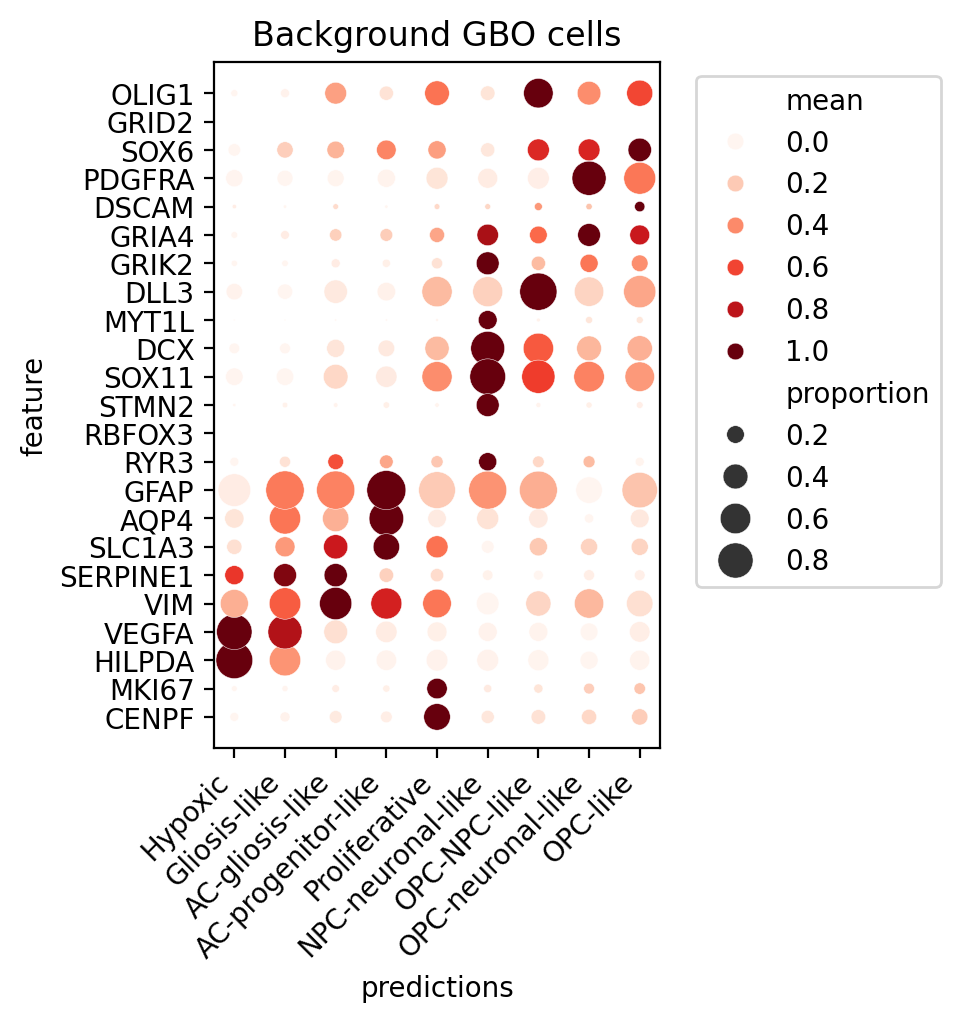

In [ ]:
plt.figure(figsize=(3.5, 5))

sns.scatterplot(data = dp_df, x = 'predictions', 
                y = 'feature', hue = 'mean', size = 'proportion',
                sizes = (0,200), palette = 'Reds',
                hue_norm=(0,1),
                size_norm=(0,1),
               )
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Background GBO cells')
plt.savefig(plot_dir+'dotplot_background_legend.pdf')

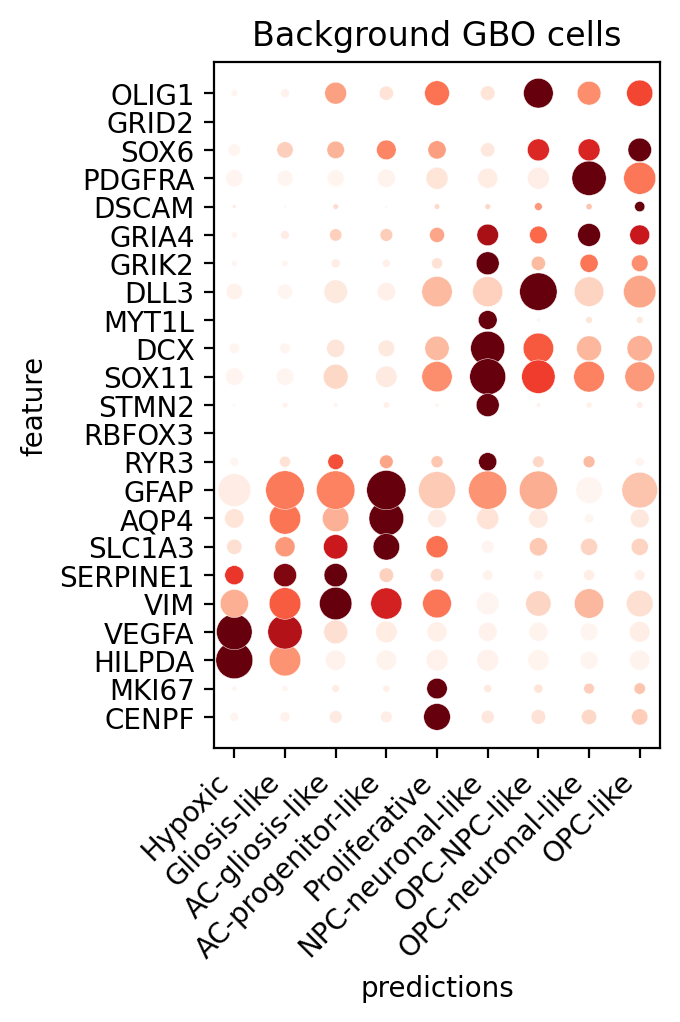

In [ ]:
plt.figure(figsize=(3.5, 5))

sns.scatterplot(data = dp_df, x = 'predictions', 
                y = 'feature', hue = 'mean', size = 'proportion',
               sizes = (0,200), palette = 'Reds')
plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
plt.title('Background GBO cells')
dp_df.to_csv('../../../data/EDFig9/EDFig9c1.csv')
plt.savefig(plot_dir+'dotplot_background.pdf')

## Engrafted cells

In [ ]:
# E25
dp_df = get_dotplot_df(
    engrafted_ad[(engrafted_ad.obs['sample_ID'].str.contains('E25')) &
                (engrafted_ad.obs['predictions'].isin(malignant_cts))], 
                       'predictions', genes,
                      standard_var = True, standard_method='minmax')

dp_df["predictions"] = pd.Categorical(
    dp_df["predictions"],
    categories=malignant_cts,
    ordered=True
)
dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

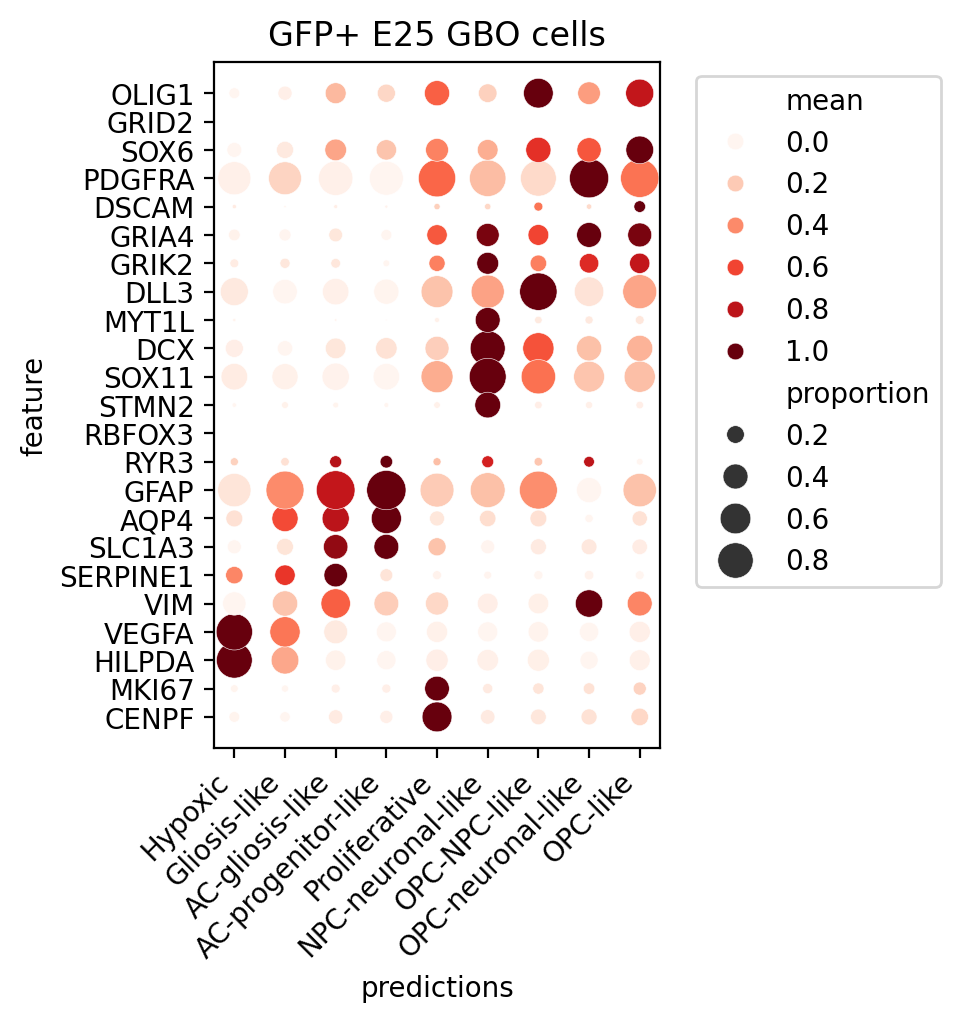

In [ ]:
plt.figure(figsize=(3.5, 5))

sns.scatterplot(data = dp_df, x = 'predictions', 
                y = 'feature', hue = 'mean', size = 'proportion',
               sizes = (0,200), palette = 'Reds')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('GFP+ E25 GBO cells')
dp_df.to_csv('../../../data/EDFig9/EDFig9c2.csv')
plt.savefig(plot_dir+'dotplot_E25.pdf')

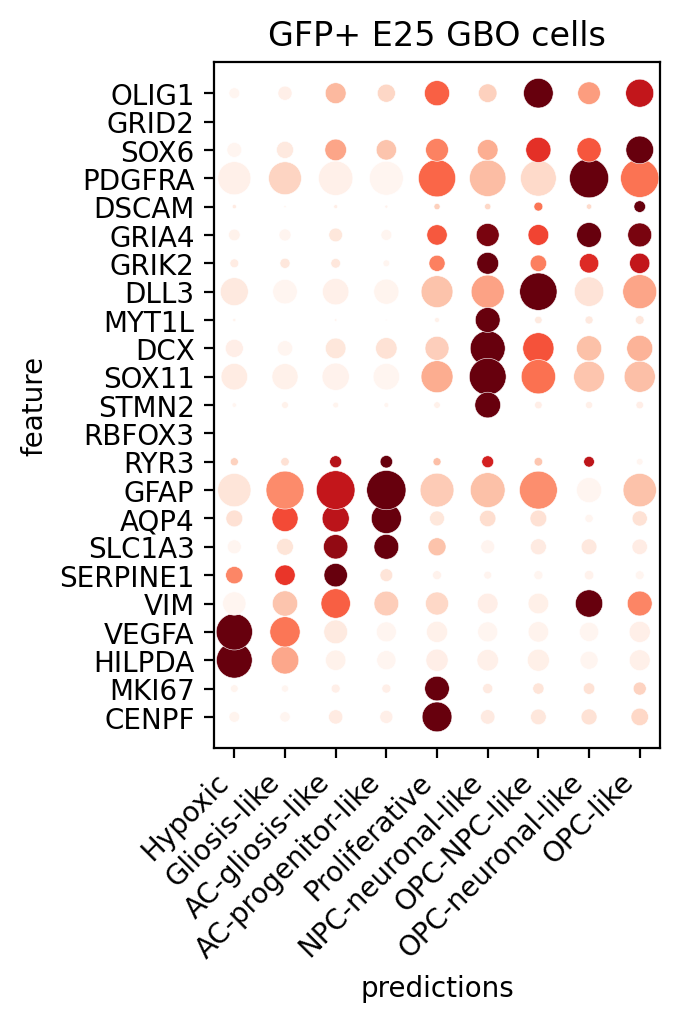

In [ ]:
plt.figure(figsize=(3.5, 5))

sns.scatterplot(data = dp_df, x = 'predictions', 
                y = 'feature', hue = 'mean', size = 'proportion',
               sizes = (0,200), palette = 'Reds')
plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
plt.title('GFP+ E25 GBO cells')
plt.savefig(plot_dir+'dotplot_E25.pdf')

In [ ]:
# E30
dp_df = get_dotplot_df(
    engrafted_ad[(engrafted_ad.obs['sample_ID'].str.contains('E30')) &
                (engrafted_ad.obs['predictions'].isin(malignant_cts))], 
                       'predictions', genes,
                      standard_var = True, standard_method='minmax')

dp_df["predictions"] = pd.Categorical(
    dp_df["predictions"],
    categories=malignant_cts,
    ordered=True
)
dp_df["feature"] = pd.Categorical(
    dp_df["feature"],
    categories=genes,
    ordered=True
)

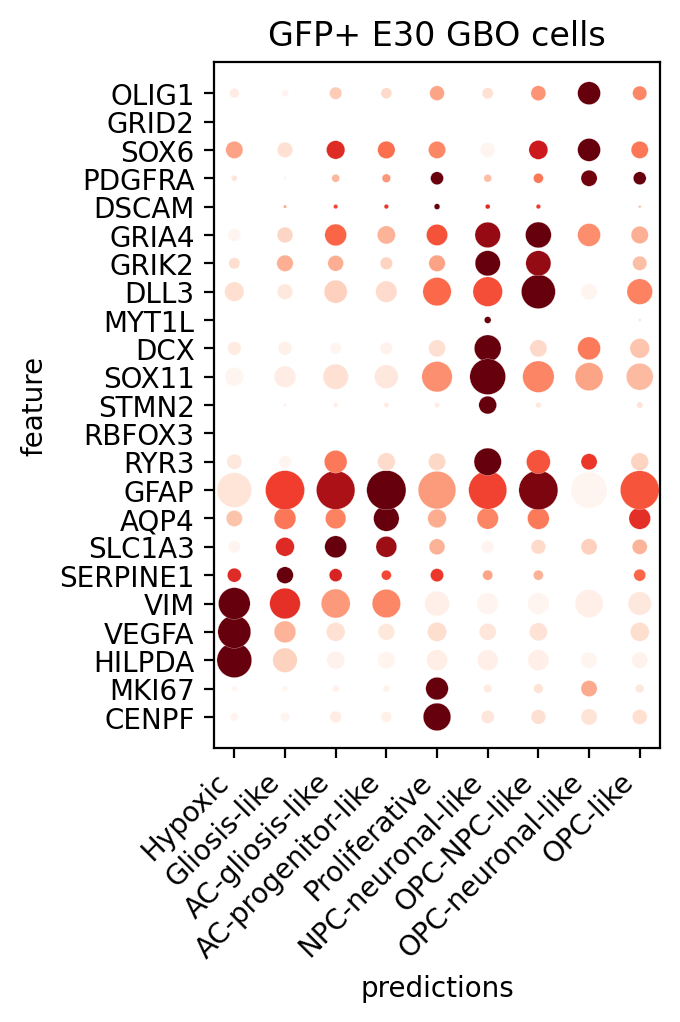

In [ ]:
plt.figure(figsize=(3.5, 5))

sns.scatterplot(data = dp_df, x = 'predictions', 
                y = 'feature', hue = 'mean', size = 'proportion',
               sizes = (0,200), palette = 'Reds')
plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
plt.title('GFP+ E30 GBO cells')
dp_df.to_csv('../../../data/EDFig9/EDFig9c3.csv')
plt.savefig(plot_dir+'dotplot_E30.pdf')

# Size analysis

## Background

In [ ]:
# may not be necessary - but for GBO cell totals
totals = background.obs\
    .groupby(['cell_line', 'time', 'lenti', 'ID'], 
             observed=True, as_index=False)['cell_id'].count()
totals['sample'] = totals['cell_line']+' '+totals['time']+' '+totals['lenti']+' '+totals['ID'].astype(str)

per_section = background.obs\
    .groupby(['cell_line', 'time', 
              'lenti', 'ID', 'batch'], 
             as_index=False, observed=True)['cell_id'].count()
per_section['sample'] = per_section['cell_line']+' '+per_section['time']+' '+per_section['lenti']+' '+per_section['ID'].astype(str)

per_section["num"] = per_section["time"].str.extract(r'(\d+)').astype(int)
per_section = per_section.sort_values("num").drop(columns="num")

In [ ]:
# gbo per section - filter GBOs by cell size to remove marginal sections
gbo_totals = per_section.groupby(['cell_line', 'ID', 'time'])['cell_id'].median()
gbo_totals = gbo_totals[gbo_totals>5000]
gbo_totals_df = gbo_totals.reset_index()[['cell_line', 'time', 'ID']]
gbo_totals_df.to_csv(plot_dir+'gbo_totals.csv')

## E25-specific

In [ ]:
from scipy.stats import pearsonr

In [ ]:
line = 'E25'

totals_df = combined_ad[
    #(combined_ad.obs['cell_line'].str.contains('e25', case=False)) &
    (combined_ad.obs['lenti']=='0.25')].obs.groupby([
    'cell_line',
    'time',
    'ID',
    'predictions'
], as_index=False)['cell_id'].count()\
    .pivot(index = ['cell_line',
                    'ID', 
                    'time'],
           columns = 'predictions', values = 'cell_id').fillna(0)
totals = totals_df.sum(axis=1)
totals.name = 'totals'

count_df = engrafted_ad.obs.groupby([ #[engrafted_ad.obs['cell_line']=='E25'].obs.groupby([
    'cell_line',
    'time',
    'ID',
    'predictions'
], as_index=False)['cell_id'].count()\
    .pivot(index = ['cell_line',
                    'ID', 
                    'time'], 
           columns = 'predictions', values = 'cell_id').fillna(0)

In [ ]:
class_count_df = []
for ct_class in ['AC-gliosis-hypoxia', 'OPC-NPC-like', 
                 'Neuron-like']:
    coarse_cts = annotation_hierarchy[annotation_hierarchy['cell_class']==ct_class]['annotation_coarse'].tolist()
    coarse_cts = list(set(coarse_cts))
    s = count_df[coarse_cts].sum(axis=1)
    s.name = ct_class
    class_count_df.append(s)
class_count_df = pd.concat(class_count_df, axis=1)
class_count_df = pd.concat([class_count_df, totals], axis=1)
class_count_df = class_count_df.reset_index()

In [ ]:
class_count_df['condition'] = class_count_df['cell_line']+' '+class_count_df['time']

0.8321025094486275 0.00041810524950248166


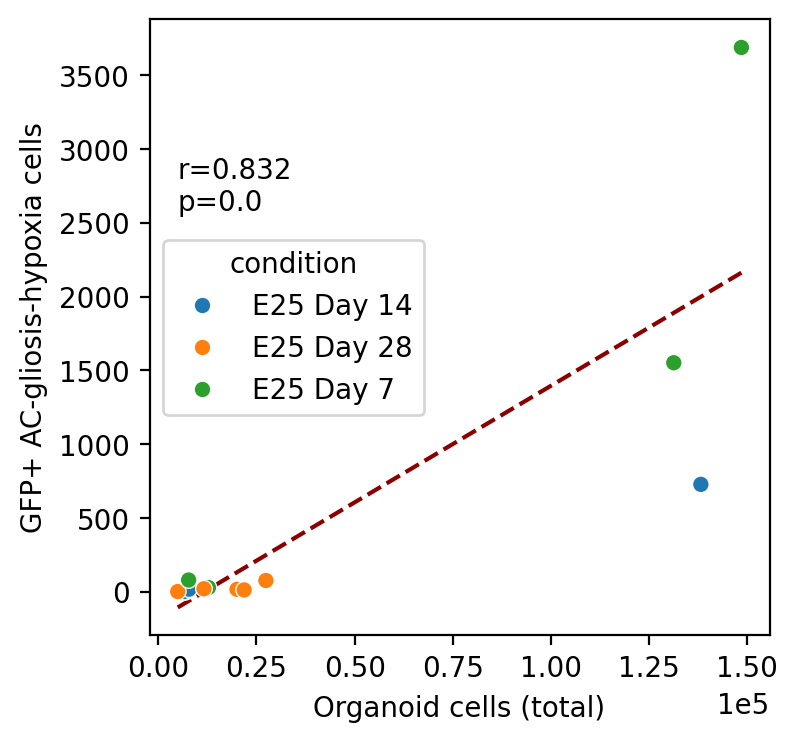

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

e25 = class_count_df[class_count_df['cell_line']=='E25']

sns.scatterplot(e25, 
                x = 'totals', y = 'AC-gliosis-hypoxia',
                hue = 'condition')


r, p_value = pearsonr(e25['totals'], e25['AC-gliosis-hypoxia'])
print(r, p_value)

x = e25['totals']
y = e25['AC-gliosis-hypoxia']
m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b, color="darkred", 
        linestyle='--', zorder=-1)

plt.text(y=e25['AC-gliosis-hypoxia'].max()*0.7, 
         x=e25['totals'].min(), 
         s='r={}\np={}'.format(round(r, 3), round(p_value,3)))

plt.xlabel('Organoid cells (total)')
plt.ylabel('GFP+ AC-gliosis-hypoxia cells')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()

0.8162825368737195 0.0021765152672792555


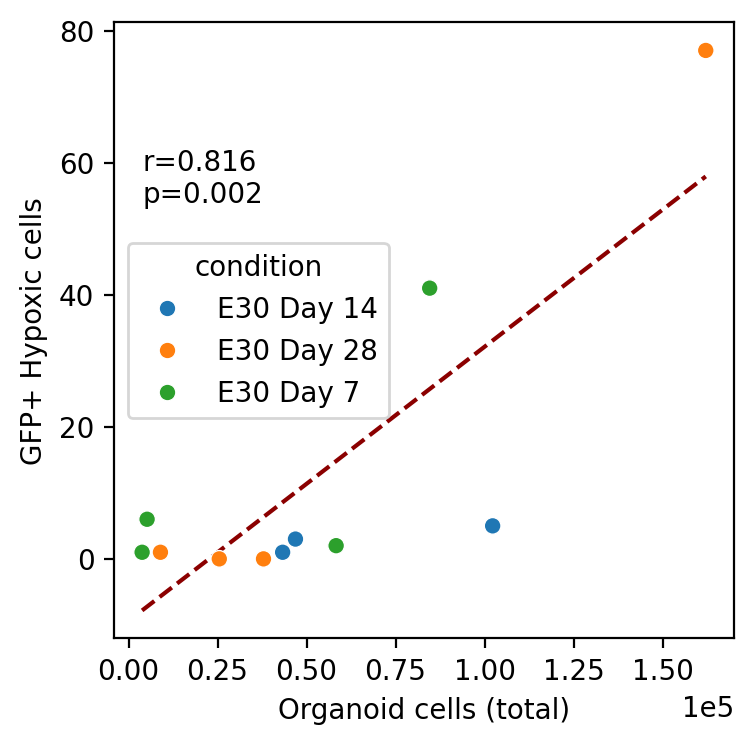

In [ ]:
## hypoxic ONLY

fig, ax = plt.subplots(figsize=(4, 4))

line_counts = count_df.copy()
line_counts = pd.concat([line_counts, totals], axis=1).reset_index()
line_counts['condition'] = line_counts['cell_line']+' '+line_counts['time']

line_counts = line_counts[line_counts['cell_line']=='E30']

sns.scatterplot(line_counts, 
                x = 'totals', y = 'Hypoxic',
                hue = 'condition')


r, p_value = pearsonr(line_counts['totals'], line_counts['Hypoxic'])
print(r, p_value)

x = line_counts['totals']
y = line_counts['Hypoxic']
m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b, color="darkred",
        linestyle='--', zorder=-1)


plt.text(y=line_counts['Hypoxic'].max()*0.7, 
         x=line_counts['totals'].min(), 
         s='r={}\np={}'.format(round(r, 3), round(p_value,3)))

plt.xlabel('Organoid cells (total)')
plt.ylabel('GFP+ Hypoxic cells')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()

0.8337225328275413 0.00039770164233587343


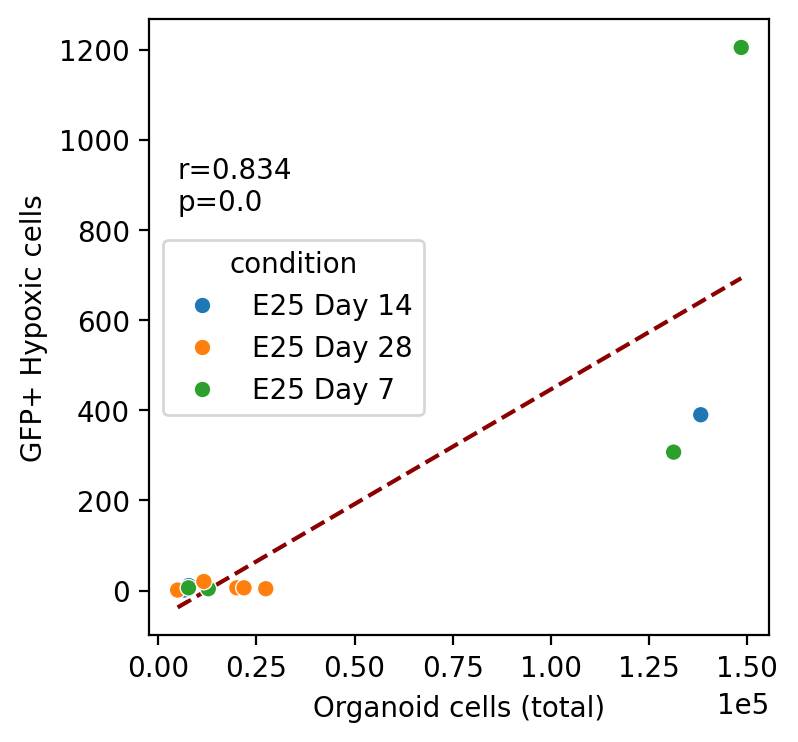

In [ ]:
## hypoxic ONLY

fig, ax = plt.subplots(figsize=(4, 4))

line_counts = count_df.copy()
line_counts = pd.concat([line_counts, totals], axis=1).reset_index()
line_counts['condition'] = line_counts['cell_line']+' '+line_counts['time']

line_counts = line_counts[line_counts['cell_line']=='E25']

sns.scatterplot(line_counts, 
                x = 'totals', y = 'Hypoxic',
                hue = 'condition')


r, p_value = pearsonr(line_counts['totals'], line_counts['Hypoxic'])
print(r, p_value)

x = line_counts['totals']
y = line_counts['Hypoxic']
m, b = np.polyfit(x, y, 1)
x_sorted = np.sort(x)
ax.plot(x_sorted, m*x_sorted + b, color="darkred",
        linestyle='--', zorder=-1)


plt.text(y=line_counts['Hypoxic'].max()*0.7, 
         x=line_counts['totals'].min(), 
         s='r={}\np={}'.format(round(r, 3), round(p_value,3)))

#plt.xscale("log")
#plt.yscale("log")
plt.xlabel('Organoid cells (total)')
plt.ylabel('GFP+ Hypoxic cells')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()

# Composition plots

In [ ]:
engrafted_ad.obs['org_ID'] = list(zip(engrafted_ad.obs["cell_line"], 
                                      engrafted_ad.obs["ID"], 
                                      engrafted_ad.obs["time"]))

filtered_ad = engrafted_ad[engrafted_ad.obs['org_ID'].isin(gbo_totals.index)]
filtered_ad.obs['use_sample'] = True 
filtered_ad.obs.to_csv(os.path.join(plot_dir, 'filtered_ad_obs.csv'))

composition_df = adata_full_obs.merge(filtered_ad.obs[['cell_id', 'batch', 'use_sample', 'ID']], 
                                      on = ['batch', 'cell_id'], how = 'left')

baseline = ['cd44- E25-MOI: 0.25',
'cd44- E30-MOI: 0.25',]

composition_df['use_sample'] = np.where(composition_df['sample_name'].isin(baseline), True, composition_df['use_sample'])
composition_df = composition_df[~composition_df['use_sample'].isnull()]

/tmp/ipykernel_1444789/876862102.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  filtered_ad.obs['use_sample'] = True


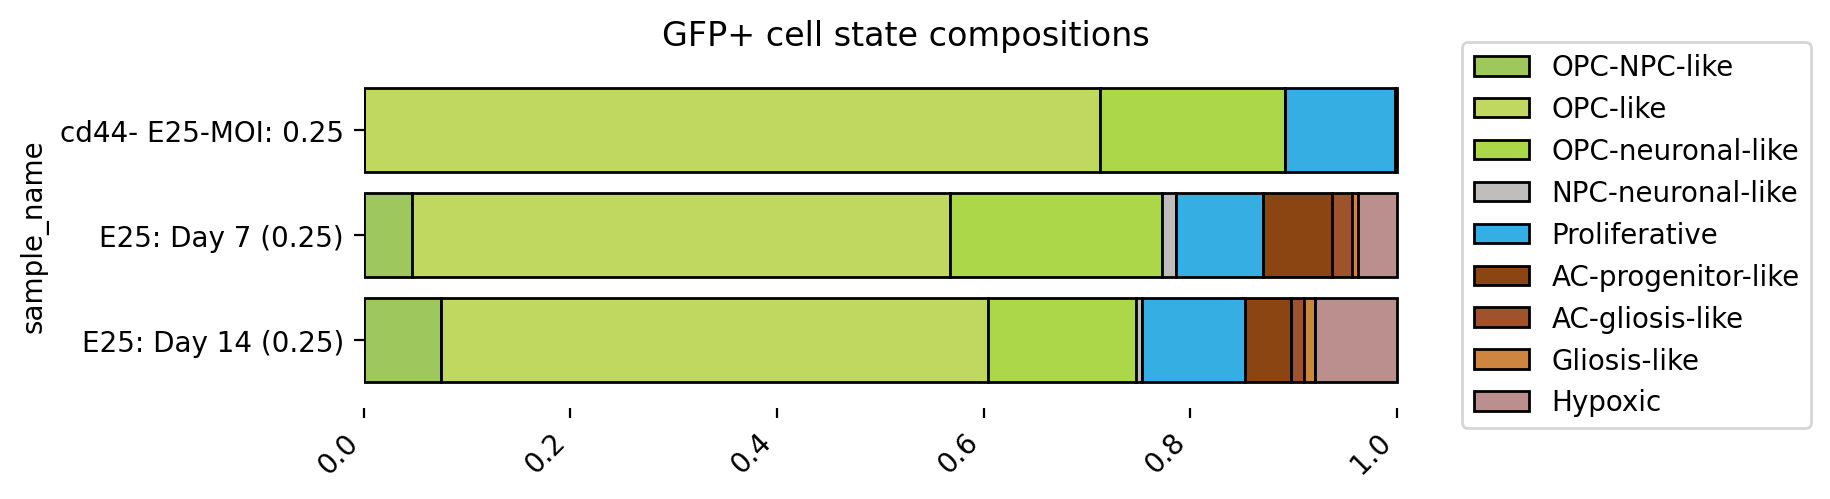

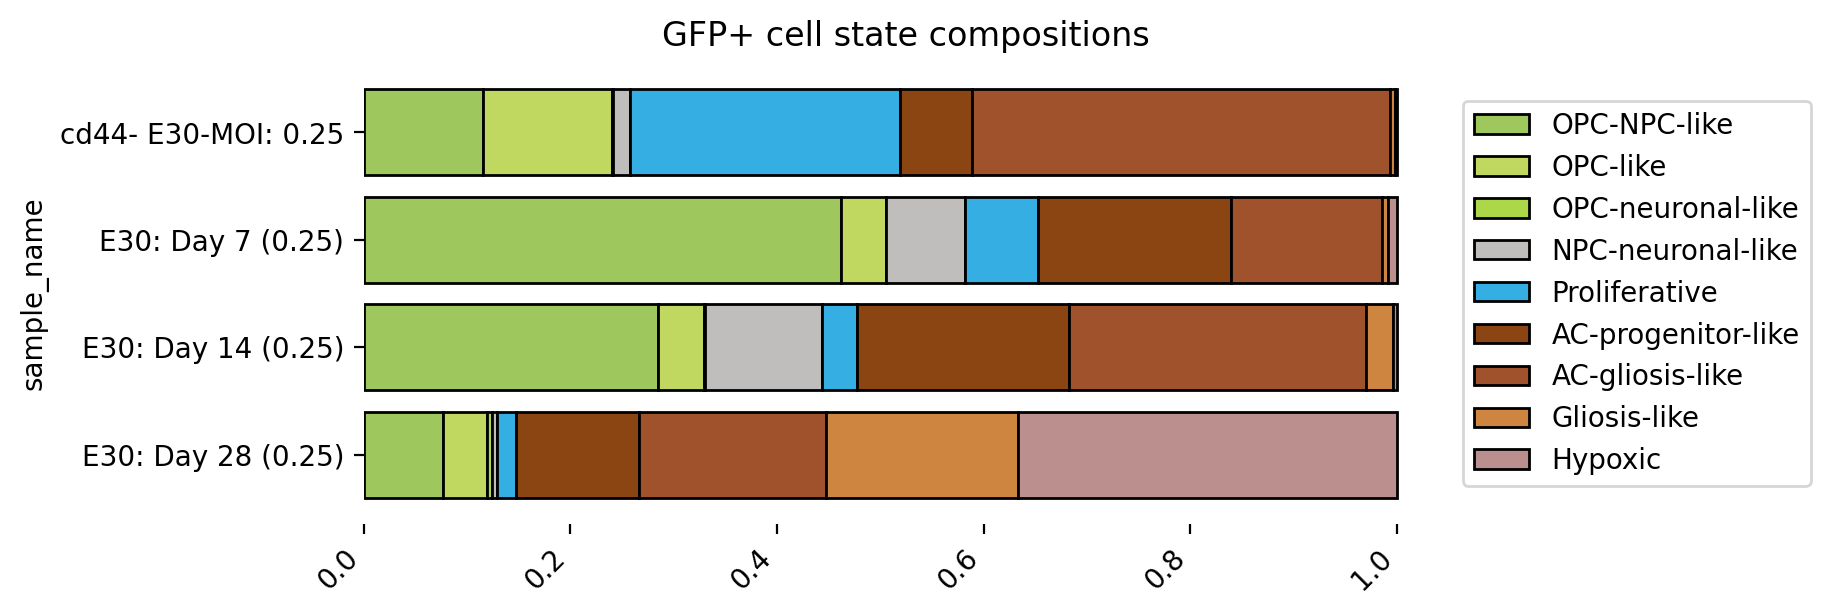

In [ ]:
count_df = composition_df.groupby([
    'sample_name',
    'predictions'
], as_index=False, observed=True)['cell_id'].count()\
    .pivot(index = ['sample_name'], 
           columns = 'predictions', values = 'cell_id').fillna(0)

order = [
    'cd44- E25-MOI: 0.25', 'E25: Day 7 (0.25)', 'E25: Day 14 (0.25)',
    'cd44- E30-MOI: 0.25', 'E30: Day 7 (0.25)', 'E30: Day 14 (0.25)' ,'E30: Day 28 (0.25)', 
]

order.reverse()

count_df = count_df.loc[order]

col_order = ['OPC-NPC-like', 'OPC-like', 'OPC-neuronal-like', 
             'NPC-neuronal-like', 'Proliferative', 'AC-progenitor-like', 
             'AC-gliosis-like', 'Gliosis-like', 'Hypoxic']
count_df = count_df[col_order]

for line in ['E25', 'E30']:

    plot_df = count_df[count_df.index.str.contains(line)]

    sf = len(plot_df)
    sf = sf/4
    
    fig, ax = plt.subplots(figsize=(7, 3*sf))
    plot_df.divide(plot_df.sum(axis=1), axis=0)\
        .plot(kind='barh', stacked=True, 
              width=0.8, edgecolor="black", linewidth=1,
              color=color_palette, ax=ax)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(rotation=45, ha="right")
    plt.title('GFP+ cell state compositions')
    ax.set_frame_on(False)
    plt.savefig(plot_dir+'scanvi_{}.pdf'.format(line))

In [ ]:
out_df = count_df.divide(count_df.sum(axis=1), axis=0)
out_df = out_df[out_df.index.isin(order)]
out_df.to_csv('../../../data/Fig5/Fig5d.csv')

In [ ]:
engrafted_counts = composition_df.groupby(['sample_name', 'batch', 'ID'], as_index=False)['cell_id'].count()
engrafted_counts['sample'] = [re.sub('\\(0.25\\)', '0.25', i) for i in engrafted_counts['sample_name']]
engrafted_counts['sample'] = [re.sub(':', '', i) for i in engrafted_counts['sample']]
engrafted_counts['sample'] = engrafted_counts['sample']+' '+engrafted_counts['ID']
engrafted_counts = engrafted_counts.rename(columns={'cell_id':'engrafted_counts'})

In [ ]:
background_counts = per_section[['sample', 'batch', 'cell_id']]
background_counts = background_counts.rename(columns={'cell_id':'background_counts'})

In [ ]:
engrafted_counts.merge(background_counts, on = ['sample', 'batch'], how = 'left')\
[['sample', 'batch', 'engrafted_counts', 'background_counts']]\
    .to_csv(plot_dir+'total_counts.csv')

# Spatial plots - selected sections for figure

In [ ]:
batch_list = {
"AT410-BRA-5-ORG-e25-MOI0_25-D7-S23-B1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad":'GSO1',
"AT410-BRA-5-ORG-E30-MOI0_25-D7-S28-B1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad":"GSO1",
"AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad":"GSO1",
"AT410-BRA-5-ORG-e25-MOI0_25-D7-S63-D1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad":"GSO1"
}

## Full GBO plots

In [ ]:
for batch in batch_list.keys():
    for sample_name in batch_list.keys():
        if 'ID' in sections[sample].obs:
            if sample_name in sample:
                sp_ad = sections[sample][sections[sample].obs['predictions'].isin(malignant_cts)]
                sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[sample_name]]
                
                with plt.rc_context({"figure.figsize": (10, 10)}):
                        sq.pl.spatial_scatter(
                            sp_ad,
                            #sp_ad[sp_ad.obs['cell_type_probability']>0.4],
                            spatial_key="spatial",
                            color="ID",
                            img=False,
                            shape=None,
                            size = 10,
                            title = sample_name,
                            #palette=cmap_all
                        )
                        plt.show()

In [ ]:
for sample in sample_list:
    for sample_name in batch_list.keys():
        if 'ID' in sections[sample].obs:
            if sample_name in sample:
                sp_ad = sections[sample][sections[sample].obs['predictions'].isin(malignant_cts)]
                sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[sample_name]]

                cmap_all = ListedColormap(
                                [color_palette[c] for c in sorted(list(set(sp_ad.obs['predictions'])))],
                                name="")
                
                with plt.rc_context({"figure.figsize": (10, 10)}):
                        sq.pl.spatial_scatter(
                            sp_ad,
                            #sp_ad[sp_ad.obs['cell_type_probability']>0.4],
                            spatial_key="spatial",
                            color="predictions",
                            img=False,
                            shape=None,
                            size = 80,
                            title = sample_name,
                            palette=cmap_all
                        )
                        plt.savefig(plot_dir+'figure_scanvi_{}.png'.format(sample_name))
                        plt.show()

In [ ]:
for batch in batch_list.keys():
    
    sp_ad = combined_ad[combined_ad.obs['batch']==batch]
    sp_ad = sp_ad[~sp_ad.obs['ID'].isnull()]
    sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[batch]]
    sp_ad = sp_ad[sp_ad.obs['predictions'].isin(malignant_cts)]


    sp_ad_GFP = sp_ad[~(sp_ad.obs['engrafted_label'].isnull())]
    sp_ad_other = sp_ad[sp_ad.obs['engrafted_label'].isnull()]
    sp_ad_other.obs['predictions'] = 'NA'
    
    cmap_GFP = ListedColormap(
        [color_palette[c] for c in sorted(list(set(sp_ad_GFP.obs['predictions'])))],
        name="")
    cmap_other = ListedColormap(
        [color_palette[c] for c in sorted(list(set(sp_ad_other.obs['predictions'])))],
        name="")
    
    with plt.rc_context({"figure.figsize": (10, 10)}):
    
        # plot NA points first (background)
        ax = sq.pl.spatial_scatter(
            sp_ad_other,
            spatial_key="spatial",
            color='predictions',
            alpha=0.01,
            size=100,
            img=False,
            shape=None,
            return_ax=True,
            palette=cmap_other
        )
        
        # plot non-NA points on top
        sq.pl.spatial_scatter(
            sp_ad_GFP,
            spatial_key="spatial",
            color='predictions',
            alpha=1.0,
            size=160,
            img=False,
            shape=None,
            ax=ax,
            palette=cmap_GFP
        )
        plt.title(batch)
        
        plt.savefig(plot_dir+'figure_scanvi_engrafted_{}.png'.format(batch))
        plt.show()

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

batch = "AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad"

sp_ad = combined_ad[combined_ad.obs['batch']==batch]
sp_ad = sp_ad[~sp_ad.obs['ID'].isnull()]
sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[batch]]
sp_ad = sp_ad[sp_ad.obs['predictions'].isin(malignant_cts)]


cts = [
 'Hypoxic',
 'Gliosis-like',
 'AC-progenitor-like',
 'OPC-NPC-like',
]
cts.reverse()

fig, ax = plt.subplots(1, len(cts), figsize=(10 * len(cts), 10))

if len(cts) == 1:
    ax = [ax]

for i, ct in enumerate(cts):
    sp_ad_ct = sp_ad[sp_ad.obs["predictions"] == ct].copy()
    sp_ad_other = sp_ad[sp_ad.obs["predictions"] != ct].copy()

    sp_ad_other.obs["predictions"] = "NA"

    cmap_ct = ListedColormap(
        [color_palette[c] for c in sorted(list(set(sp_ad_ct.obs['predictions'])))],
        name="")
    cmap_other = ListedColormap(
        [color_palette[c] for c in sorted(list(set(sp_ad_other.obs['predictions'])))],
        name="")

    # background first
    sq.pl.spatial_scatter(
        sp_ad_other,
        spatial_key="spatial",
        color="predictions",
        alpha=0.3,
        size=30,
        img=False,
        shape=None,
        ax=ax[i],
        palette=cmap_other,
        legend_loc=None,
    )

    # foreground second
    sq.pl.spatial_scatter(
        sp_ad_ct,
        spatial_key="spatial",
        color="predictions",
        alpha=1.0,
        size=90,
        img=False,
        shape=None,
        ax=ax[i],
        palette=cmap_ct,
        legend_loc=None,
    )

    ax[i].set_title(ct)
    ax[i].set_frame_on(False)
    ax[i].axis("off")

    # flatten only the plotted points
    for coll in ax[i].collections:
        coll.set_rasterized(True)

fig.subplots_adjust(wspace=-0.75, hspace=-0.75)
plt.suptitle(batch)
plt.tight_layout()
plt.savefig(plot_dir+'figure_panel_{}.pdf'.format(batch))

## Gene expression

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import squidpy as sq
from mpl_toolkits.axes_grid1 import make_axes_locatable

batch = "AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad"

sp_ad = combined_ad[combined_ad.obs['batch']==batch].copy()
sp_ad = sp_ad[~sp_ad.obs['ID'].isnull()]
sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[batch]]
sp_ad = sp_ad[sp_ad.obs['predictions'].isin(malignant_cts)]

sc.pp.normalize_total(sp_ad, target_sum=1e4)
sc.pp.log1p(sp_ad)
                

genes_map = {
 'OLIG1':color_palette['OPC-NPC-like'],
 'AQP4':color_palette['AC-progenitor-like'],
 'SERPINE1':color_palette['Gliosis-like'],
 'HILPDA':color_palette['Hypoxic']
}

fig, ax = plt.subplots(1, len(cts), figsize=(10 * len(cts), 10))

if len(cts) == 1:
    ax = [ax]

for i, gene in enumerate(genes_map.keys()):

    cmap = LinearSegmentedColormap.from_list("custom", ["white", genes_map[gene]])

    p95 = np.quantile(sp_ad[:,sp_ad.var_names==gene].X.toarray(), 0.95)
    sp_ad.obs['exp'] = sp_ad[:,sp_ad.var_names==gene].X.toarray()

    # foreground second
    sq.pl.spatial_scatter(
        sp_ad[sp_ad.obs['exp']>0],
        spatial_key="spatial",
        color=gene,
        alpha=1.0,
        size=120,
        img=False,
        shape=None,
        ax=ax[i],
        cmap=cmap,
        legend_loc=None,
        vmax=p95,
        colorbar=False
    )

    ax[i].set_title(gene)
    ax[i].set_frame_on(False)
    ax[i].axis("off")

    # get the plotted artist for this subplot
    mappable = ax[i].collections[0]

    # add a bottom colorbar axis just for this subplot
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="3%", pad=-0.8)

    cbar = fig.colorbar(mappable, cax=cax, orientation="vertical")
    cbar.set_label(gene)

    # flatten only the plotted points
    for coll in ax[i].collections:
        coll.set_rasterized(True)

fig.subplots_adjust(wspace=-0.5, hspace=-0.5)
plt.suptitle(batch)
plt.tight_layout()
plt.savefig(plot_dir+'figure_panel_genes_{}.pdf'.format(batch))

In [ ]:
# export keys for spatialdata 
obs_dir = "../../../data/xenium_data/annotation_obs/"
for batch in batch_list.keys():
    sp_ad = combined_ad[combined_ad.obs['batch']==batch]
    sp_ad = sp_ad[sp_ad.obs['ID']==batch_list[batch]]
    sp_ad = sp_ad[sp_ad.obs['predictions'].isin(malignant_cts)]
    sp_ad.obs['engrafted'] = np.where(sp_ad.obs['engrafted_label'].isnull(), False, True)

    sample_name_out = re.sub('__.*$', '', batch)
    sp_ad.obs[['cell_id', 'predictions', 'engrafted']].to_csv(obs_dir+sample_name_out+'.csv', index=False)

    sq.pl.spatial_scatter(
        sp_ad,
        spatial_key="spatial",
        color="predictions",
        alpha=1.0,
        size=2,
        img=False,
        shape=None,
        legend_loc=None,
    )

# Time series per organoid

/tmp/ipykernel_1430274/3888531619.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline['sample_ID'] = 'E25 baseline Day 0'


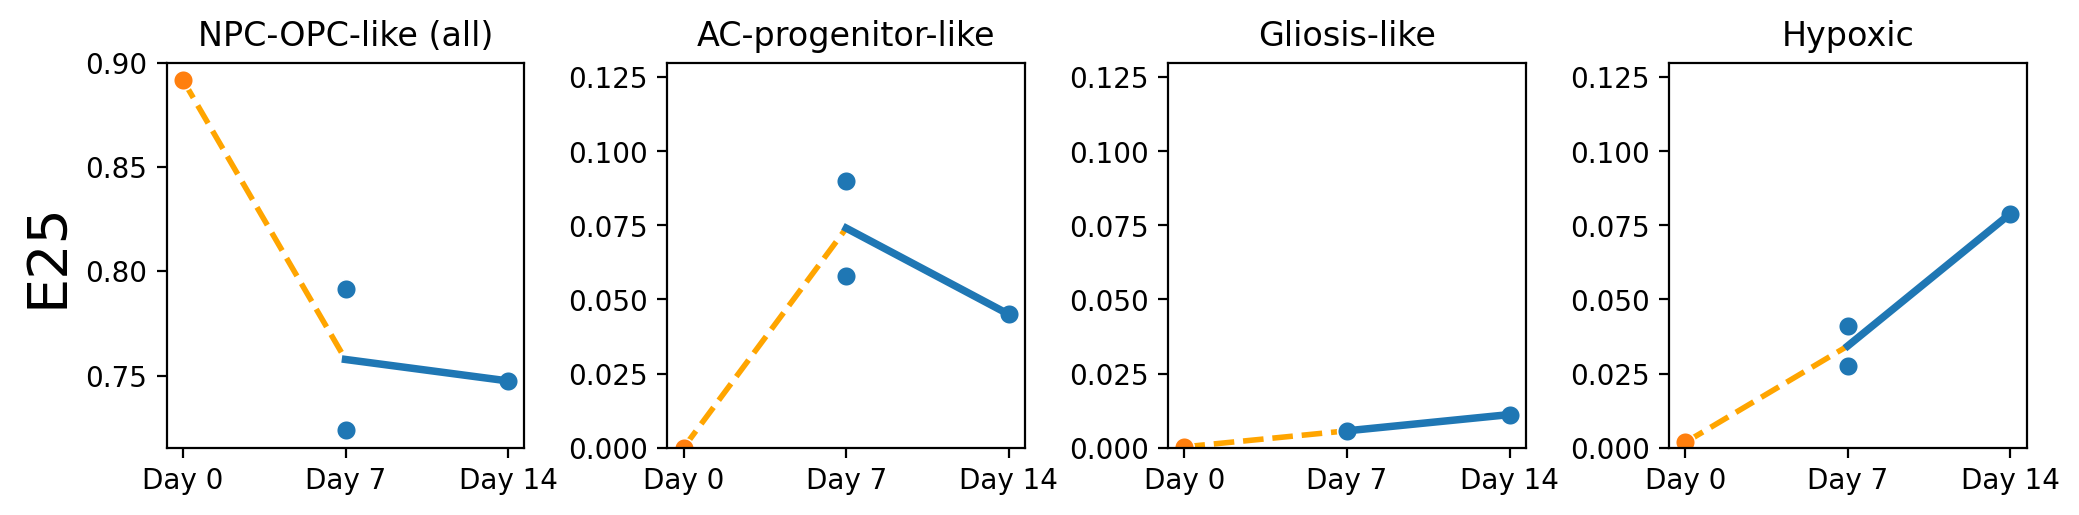

In [ ]:
line = 'E25'
cell_type_col = 'predictions'
cts = ['NPC-OPC-like (all)', 'AC-progenitor-like', 'Gliosis-like', 'Hypoxic']

# add 0 time point
baseline = adata_full_obs[(adata_full_obs['sample_name']=='cd44- {}-MOI: 0.25'.format(line))]
baseline['sample_ID'] = 'E25 baseline Day 0'
baseline = baseline.groupby([
    'sample_ID',  
], as_index=False)[cell_type_col].value_counts(normalize=True)

# add baseline cell with 0 counts
ct_missing = [i for i in cts if i not in baseline[cell_type_col].tolist()]
baseline = pd.concat([baseline, pd.DataFrame({
    'sample_ID':['{} baseline Day 0'.format(line)]*len(ct_missing),
    cell_type_col:ct_missing, 'proportion':[0]*len(ct_missing)
})])

# get main df
plot_df = filtered_ad[filtered_ad.obs['cell_line']==line].obs.copy()
plot_df[cell_type_col] = pd.Categorical(plot_df[cell_type_col],)
plot_df = plot_df.groupby([
    'sample_ID', 
    #'time'
], as_index=False)[cell_type_col].value_counts(normalize=True)

# add missing main
plot_df = pd.concat([plot_df, baseline])

plot_df["time"] = [re.sub('^.*Day', 'Day', i) for i in plot_df["sample_ID"]]
plot_df["time"] = pd.Categorical(
    plot_df["time"],
    categories=["Day 0", "Day 7", "Day 14", "Day 28"],
    ordered=True
)

# combine OPC-likes
to_merge = {'OPC-like', 'OPC-NPC-like', 'OPC-neuronal-like'}
plot_df = plot_df.assign(
    group_merged=plot_df['predictions'].where(~plot_df['predictions'].isin(to_merge), 
                                              'NPC-OPC-like (all)'))
plot_df = plot_df.drop('predictions', axis=1).groupby(['sample_ID', 
                                                       'time', 
                                                       'group_merged'], 
                                            observed=True, as_index=False).sum()
# reassign cell type col
cell_type_col = 'group_merged'

plot_df.to_csv('../../../data/EDFig9/EDFig9e1.csv')

fig, ax = plt.subplots(1, len(cts), figsize=(len(cts)*3, 2.5), sharey = False)

for i,ct in enumerate(cts):

    df_main = plot_df[plot_df['time'].isin(['Day 7', 'Day 14', 'Day 28'])]
    df_base = plot_df[plot_df['time']=='Day 0']
    
    sns.pointplot(
        data=df_main[df_main[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        estimator="mean",
        errorbar=None,   # 🔑 removes error bars
        markers=None,
        color="C0"
    )

    sns.scatterplot(
        data=df_main[df_main[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        color="#1f77b4",
        s = 50
    )

    sns.scatterplot(
        data=df_base[df_base[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        color="#ff7f0e",
        s = 50
    )

    d7_mean = plot_df[(plot_df[cell_type_col]==ct) & 
        (plot_df['time']=='Day 7')]['proportion'].mean()
    d0_mean = df_base[df_base[cell_type_col]==ct]['proportion'].mean()
    
    ax[i].plot(
        [0, 1],
        [d0_mean, d7_mean],
        linestyle="--",   # dashed line
        color="orange",
        linewidth=2,
        zorder = -1
    )
    
    #ax[i].set_ylim(0,1)
    ax[i].set_xlabel("")
    ax[i].set_title(ct)

    if i==0:
        ax[i].set_ylabel(line, size = 20)
    else:
        ax[i].set_ylabel("")
    if ct not in ['NPC-OPC-like (all)', 'Proliferative']:
        ax[i].set_ylim(0,0.13)
    elif ct=='Proliferative':
        ax[i].set_ylim(0,0.20)

# Remove ALL spacing between plots
plt.subplots_adjust(wspace=0.4, hspace=0)

plt.savefig(plot_dir+'GSO_proportions_scanvi_{}.pdf'.format(line))
plt.show()

/tmp/ipykernel_1430274/3414870120.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline['sample_ID'] = 'E30 baseline Day 0'


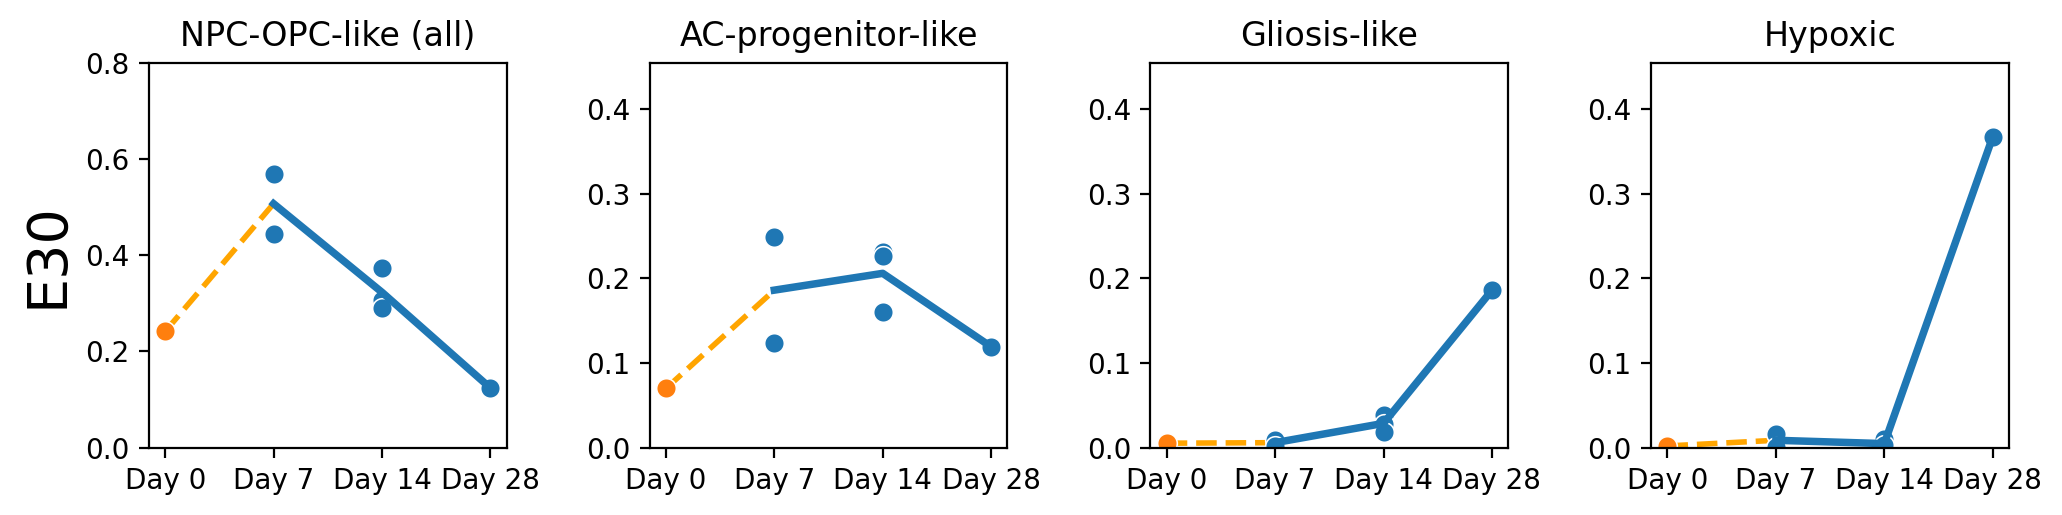

In [ ]:
line = 'E30'
cell_type_col = 'predictions'
cts = ['NPC-OPC-like (all)', 'AC-progenitor-like', 'Gliosis-like', 'Hypoxic']

# add 0 time point
baseline = adata_full_obs[(adata_full_obs['sample_name']=='cd44- {}-MOI: 0.25'.format(line))]
baseline['sample_ID'] = 'E30 baseline Day 0'
baseline = baseline.groupby([
    'sample_ID',  
], as_index=False)[cell_type_col].value_counts(normalize=True)

# add baseline cell with 0 counts
ct_missing = [i for i in cts if i not in baseline[cell_type_col].tolist()]
baseline = pd.concat([baseline, pd.DataFrame({
    'sample_ID':['{} baseline Day 0'.format(line)]*len(ct_missing),
    cell_type_col:ct_missing, 'proportion':[0]*len(ct_missing)
})])

# get main df
plot_df = filtered_ad[filtered_ad.obs['cell_line']==line].obs.copy()
plot_df[cell_type_col] = pd.Categorical(plot_df[cell_type_col],)
plot_df = plot_df.groupby([
    'sample_ID', 
    #'time'
], as_index=False)[cell_type_col].value_counts(normalize=True)

# add missing main
plot_df = pd.concat([plot_df, baseline])

plot_df["time"] = [re.sub('^.*Day', 'Day', i) for i in plot_df["sample_ID"]]
plot_df["time"] = pd.Categorical(
    plot_df["time"],
    categories=["Day 0", "Day 7", "Day 14", "Day 28"],
    ordered=True
)

# combine OPC-likes
to_merge = {'OPC-like', 'OPC-NPC-like', 'OPC-neuronal-like'}
plot_df = plot_df.assign(
    group_merged=plot_df['predictions'].where(~plot_df['predictions'].isin(to_merge), 
                                              'NPC-OPC-like (all)'))
plot_df = plot_df.drop('predictions', axis=1).groupby(['sample_ID', 
                                                       'time', 
                                                       'group_merged'], 
                                            observed=True, as_index=False).sum()
# reassign cell type col
cell_type_col = 'group_merged'


plot_df.to_csv('../../../data/EDFig9/EDFig9e2.csv')

fig, ax = plt.subplots(1, len(cts), figsize=(len(cts)*3, 2.5), sharey = False)

for i,ct in enumerate(cts):

    df_main = plot_df[plot_df['time'].isin(['Day 7', 'Day 14', 'Day 28'])]
    df_base = plot_df[plot_df['time']=='Day 0']
    
    sns.pointplot(
        data=df_main[df_main[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        estimator="mean",
        errorbar=None,   # 🔑 removes error bars
        markers=None,
        color="C0"
    )

    sns.scatterplot(
        data=df_main[df_main[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        color="#1f77b4",
        s = 50
    )

    sns.scatterplot(
        data=df_base[df_base[cell_type_col]==ct],
        x="time",
        y="proportion",
        ax = ax[i],
        color="#ff7f0e",
        s = 50
    )

    d7_mean = plot_df[(plot_df[cell_type_col]==ct) & 
        (plot_df['time']=='Day 7')]['proportion'].mean()
    d0_mean = df_base[df_base[cell_type_col]==ct]['proportion'].mean()
    
    ax[i].plot(
        [0, 1],
        [d0_mean, d7_mean],
        linestyle="--",   # dashed line
        color="orange",
        linewidth=2,
        zorder = -1
    )
    
    #ax[i].set_ylim(0,1)
    ax[i].set_xlabel("")
    ax[i].set_title(ct)

    if i==0:
        ax[i].set_ylabel(line, size = 20)
    else:
        ax[i].set_ylabel("")
    if ct!='NPC-OPC-like (all)':
        ax[i].set_ylim(0,df_base['proportion'].max()+0.05)
    else:
        ax[i].set_ylim(0,0.8)

    

# Remove ALL spacing between plots
plt.subplots_adjust(wspace=0.4, hspace=0)

plt.savefig(plot_dir+'GSO_proportions_scanvi_{}.pdf'.format(line))
plt.show()